**What is R-squared?**

Imagine you're trying to predict your friend's mood based on how many hours of sleep they got last night. R-squared is a number that tells you how much of their mood can be explained by just that one factor: sleep.

Think of it like a percentage:

**100% R-squared (or 1.0):** This would mean that 100% of your friend's mood is perfectly explained by how much they slept. If they get 8 hours, they're always happy. If they get 4, they're always grumpy. It's a perfect relationship.

**0% R-squared (or 0.0):** This would mean that sleep has nothing to do with their mood. The R-squared value is 0 because there is no relationship between the two variables. Their mood is a coin toss, regardless of how much they slept.

**70% R-squared (or 0.7):** This means that 70% of the ups and downs in your friend's mood can be explained by their sleep. The other 30% is due to other things—maybe they had a bad day at school, or they're hungry.

**In short, R-squared is a simple way to measure how well a model fits the data. The closer the number is to 1, the better your model is at explaining what's happening.**


In [26]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Sample data: We'll make up some numbers for daily temp and ice cream sales.
# Notice how sales generally go up with temperature.
data = {'temperature': [20, 25, 22, 28, 30, 26, 31, 29, 24, 27],
        'ice_cream_sales': [100, 150, 120, 180, 200, 160, 210, 190, 140, 170]}
df = pd.DataFrame(data)

# Our variables:
# X (the thing we're using to predict) is the temperature
# y (the thing we're trying to predict) is the ice cream sales
X = df[['temperature']]
y = df['ice_cream_sales']

# Create a simple "predictor" (a linear regression model)
predictor = LinearRegression()

# Tell the predictor to "learn" from our data
predictor.fit(X, y)

# Ask the predictor to make its guesses for sales based on our temperatures
predicted_sales = predictor.predict(X)

# Now we calculate the R-squared. This tells us how good the predictor's guesses were.
r_squared = r2_score(y, predicted_sales)

print(f"R-squared value: {r_squared:.2f}")

# The output will be something around 0.96.
# This means that about 96% of the changes in ice cream sales can be explained by the daily temperature. That's a very good fit!

print("This code is slightly messed up, there is a perfect correlation (every 1 degree correlates with 10 sales starting from a 10 degree baseline)")

R-squared value: 1.00
This code is slightly messed up, there is a perfect correlation (every 1 degree correlates with 10 sales starting from a 10 degree baseline)


**Assignment 1: Temperature vs. Sales**
Goal: Understand how a variable's relevance affects R-squared.

Start with the provided Python example. Run the code and observe the R-squared value. What does this number tell you about the relationship between temperature and ice cream sales?

**Change the data:** In the data dictionary, replace the temperature list with random numbers that have no clear relationship to the ice_cream_sales. For example, use numbers like [45, 10, 32, 6, 50, 21, 15, 40, 5, 29].

Run the code again: Re-run the script with the new data. What is the R-squared value now?

**Explain:** Why did the R-squared value drop so much? What does the new, lower number mean in the context of our ice cream sales model?

In [39]:
data = {'temperature': [45, 10, 32, 6, 50, 21, 15, 40, 5, 29],
        'ice_cream_sales': [100, 150, 120, 180, 200, 160, 210, 190, 140, 170]}
df = pd.DataFrame(data)

X = df[['temperature']]
y = df['ice_cream_sales']

predictor = LinearRegression()
predictor.fit(X, y)
predicted_sales = predictor.predict(X)

r_squared = r2_score(y, predicted_sales)
print(f"R-squared value: {r_squared:.2f}")
print(f"The r-squared value of {r_squared:.2f} is so low becuase the independent variables (temperature) are completely random. What this means in the sale of ice cream, is that no sales are explain by temperature. If a 100 degree day sells 1000 ice creams, its not because of the temperature, because a 10 degree day could do the same")

R-squared value: 0.00
The r-squared value of 0.00 is so low becuase the independent variables (temperature) are completely random. What this means in the sale of ice cream, is that no sales are explain by temperature. If a 100 degree day sells 1000 ice creams, its not because of the temperature, because a 10 degree day could do the same


**Assignment 2: Predicting Test Scores**
Goal: See how a model's complexity relates to its R-squared value.

Create a dataset: Make a pandas DataFrame with three columns: hours_studied, hours_slept, and test_score.

**Add data:** Populate the dataset with at least 10 rows of numbers. Try to make both hours_studied and hours_slept have a positive relationship with test_score.

**Model 1:** Build a linear regression model that uses only hours_studied to predict test_score. Calculate and print the R-squared value.

**Model 2:** Build a new linear regression model that uses both hours_studied and hours_slept to predict test_score. Calculate and print the R-squared value for this new model.

**Compare:** Is the R-squared value higher for the second model? Why do you think adding more relevant information (hours_slept) improved the model's ability to explain the data?

In [51]:
# Your code here
df = pd.DataFrame({'hours_studied': [0, 2, 3, 1, 5, 6, 3, 8, 2, 0],
     'hours_slept': [6, 7, 8, 3 , 4, 6, 3, 6, 7, 8],
     'test_scores': [65, 83, 89, 42, 85, 92, 63, 98, 81, 70]})

X = df[['hours_studied','hours_slept']]
X1 = df[['hours_studied']]
X2 = df[['hours_slept']]
y = df['test_scores']

predictor = LinearRegression()
predictor1 = LinearRegression()
predictor2 = LinearRegression()

predictor.fit(X, y)
predictor1.fit(X1, y)
predictor2.fit(X2, y)

predicted_scores = predictor.predict(X)
predicted_scores1 = predictor1.predict(X1)
predicted_scores2 = predictor2.predict(X2)

r_squared = r2_score(y, predicted_scores)
r_squared1 = r2_score(y, predicted_scores1)
r_squared2 = r2_score(y, predicted_scores2)

print(f"""The r^2 for only hours studied and hours slept are {r_squared1:.2f} and {r_squared2:.2f} respectively.
However, when we use both variables, we see that the r^2 jumps up to {r_squared:.2f}. This is because the additional data helps paint a better picture of the data.
This means that BOTH hours slept and studied explain {r_squared*100:.2f}% of the variance in the data.
Adding more relevant information helps the model's ability to explain data becuase there are numerous factors that go into test scores. Adding more, gives a better prediction.
You could also add something like confidence or IQ, both of which would likely explain a minor portion of the data, improving the model's ability and r^2.
""")


The r^2 for only hours studied and hours slept are 0.51 and 0.28 respectively.
However, when we use both variables, we see that the r^2 jumps up to 0.91). This is because the additional data helps paint a better picture of the data.
This means that BOTH hours slept and studied explain 91.08% of the variance in the data.
Adding more relevant information helps the model's ability to explain data becuase there are numerous factors that go into test scores. Adding more, gives a better prediction.
You could also add something like confidence or IQ, both of which would likely explain a minor portion of the data, improving the model's ability and r^2.



**Assignment 3: Misleading R-squared**
**Goal:** Understand that a high R-squared doesn't always mean a good model.

**Create a curved dataset:** In a new Python script, create a DataFrame with x and y columns. Set x to a range of numbers from -5 to 5. Set y to be calculated using the formula y = x**2. This will create a U-shaped curve.

**Fit a straight line:** Use LinearRegression to fit a straight line to this curved data.

**Calculate and print:** Print the R-squared value. It might be surprisingly high, even though the line doesn't fit the curve well.

**Plot the data:** Use a plotting library like Matplotlib to create a scatter plot of your x and y points. Then, plot the straight line from your LinearRegression model on the same graph.

Analyze: Looking at the plot, does the straight line accurately represent the data? Why is R-squared high even though the model is clearly a bad fit? This shows that R-squared is a great metric, but it should be used with other checks, like a visual inspection of the data and the model's predictions.

0.0
0.9213759213759214


Text(0.5, 1.0, 'Scatter Plot vs Linear Regression')

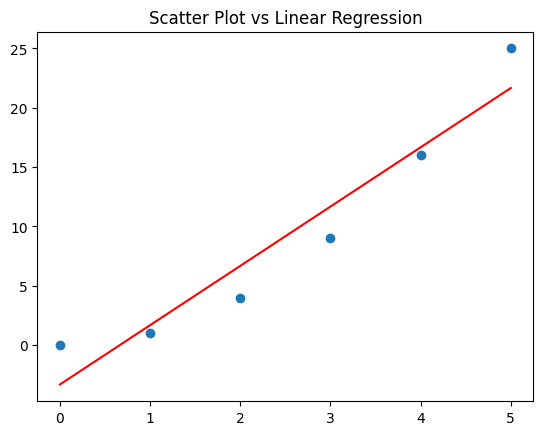

In [62]:
import matplotlib.pyplot as plt
df = pd.DataFrame({'x_var':[-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                   'y_var':[25, 16, 9, 4, 1, 0, 1, 4, 9, 16, 25]})
X = df[['x_var']]
y = df['y_var']

predictor = LinearRegression()
predictor.fit(X, y)
predicted_output = predictor.predict(X)

r_squared = r2_score(y, predicted_output)


print(r_squared)
#Assignment may have been incorrect, r^2 value is 0, perhaps it was values only from 0 to 5, not -5 to 5?
df = pd.DataFrame({'x_var':[0, 1, 2, 3, 4, 5],
                   'y_var':[0, 1, 4, 9, 16, 25]})
X = df[['x_var']]
y = df['y_var']

predictor = LinearRegression()
predictor.fit(X, y)
predicted_output = predictor.predict(X)

r_squared = r2_score(y, predicted_output)


print(r_squared)
#Higher r^2 of 0.92

plt.scatter(X, y)
plt.plot(X, predicted_output, color='red')
plt.title('Scatter Plot vs Linear Regression')
print("""
The r-squared is high even though the model is a bad fit because on a small scale, the devation between linear and quadratic points along their parent functions is low.
The linear regression, although close to the scatterplot, loses the actual pattern from the points. In turn, the r-squared is high while the regression is clearly misrepresenting the data.
This is why plotting is critical, a simply r-squared value can't tell you everything about the data.
Plotting and actually looking at the data is the only way to get a full picture of the data, and can be vital for catching errors like a misleading r-squared value (along with other ways of checking).
""")
